# (10) grad: (T, beta) = (32, 64.0)

project = ```iP-VAE```, host = ```yoru```, device = ```cuda:1```

**Motivation**: <br>

Added a single global multiplicative contrast term to ```self.phi```: bad idea

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
# from analysis.eval import sparse_score
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from figures.analysis import plot_convergence
from figures.imgs import plot_weights


device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: yoru

## Trainer

In [3]:
model_type = 'poisson'

cfg_vae, cfg_tr = default_configs('vH16', model_type, 'grad|lin')
cfg_vae['seq_len'] = 32 # 16
cfg_vae['n_iters'] = 1

cfg_vae['track_stats'] = False

cfg_vae['beta_inner'] = 1.0
cfg_tr['kl_beta'] = 64.0 # 20.0

print(f"VAE:\n{cfg_vae}\n\nTrainer:\n{cfg_tr}")

VAE:
{'dataset': 'vH16', 'n_latents': 512, 'clamp_prior': -4, 'clamp_du': 10.0, 'clamp_u': 8.0, 'inf_type': 'grad', 
'dec_type': 'lin', 'init_dist': 'normal', 'init_scale': 0.0001, 'seq_len': 32, 'n_iters': 1, 'track_stats': False, 
'beta_inner': 1.0}

Trainer:
{'batch_size': 200, 'epochs': 300, 'grad_clip': 200, 'kl_beta': 64.0}

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  132.3 K   |
|     ———     |    ———     |
|    layer    |  132.3 K   |
+-------------+------------+

poisson_vH16_t-32_z-[512]_<grad|lin>
b200-ep300-lr(0.002)_beta(64:0x0.1)_temp(0.05:lin-0.5)_gr(200)_(2025_02_12,03:22)

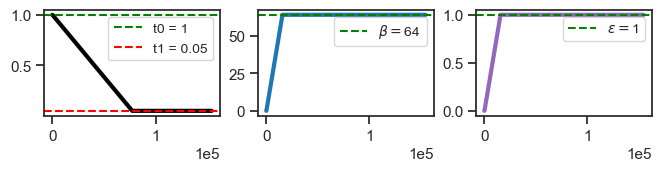

In [4]:
mod = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(mod, ConfigTrain(**cfg_tr), device=device)

mod.print()
print(f"{mod.cfg.name()}\n{tr.cfg.name()}_({mod.timestamp})\n")
tr.show_schedules()

In [5]:
print(tr.model.layer)

PoissonLayer(input_dim=256,latent_dim=512, beta_inner=1, temp=1)

In [6]:
tr.model.layer.log_bias.shape, tr.model.layer.log_lr

(torch.Size([1, 512]),
 Parameter containing:
 tensor([0.], device='cuda:1', requires_grad=True))

In [7]:
tr.model.layer.update_n_exp(11.0)
tr.model.layer.n_exp

tensor([30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30,
        30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30],
       device='cuda:1', dtype=torch.int32)

In [ ]:
# cm = ''
# tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

tr.train()

epoch # 193, avg loss: 215.925067:  64%|█▎| 193/300 [3:42:24<2:02:26, 68.66s/it]

In [9]:
print(tr.model.layer.n_exp)

tensor([22, 27, 32, 40, 49, 59, 69, 78, 84, 89, 93, 95, 97, 98, 98, 99, 99, 98,
        99, 99, 99, 99, 99, 99, 98, 98, 98, 98, 98, 98, 98, 98],
       device='cuda:1', dtype=torch.int32)

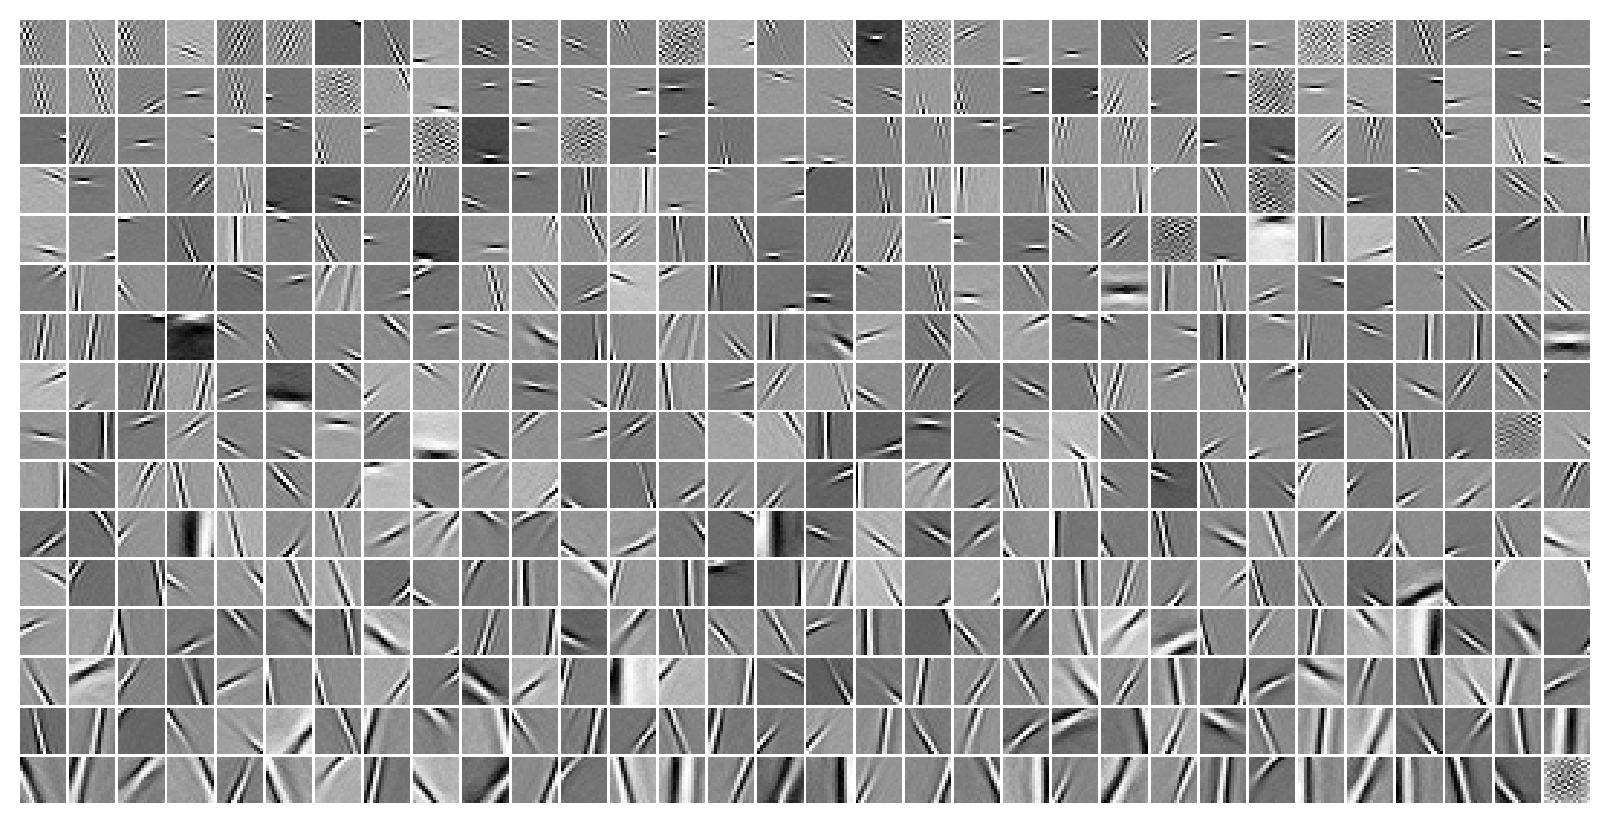

In [10]:
u0 = tonp(tr.model.layer.u_init.squeeze())
tr.model.show(order=np.argsort(u0));

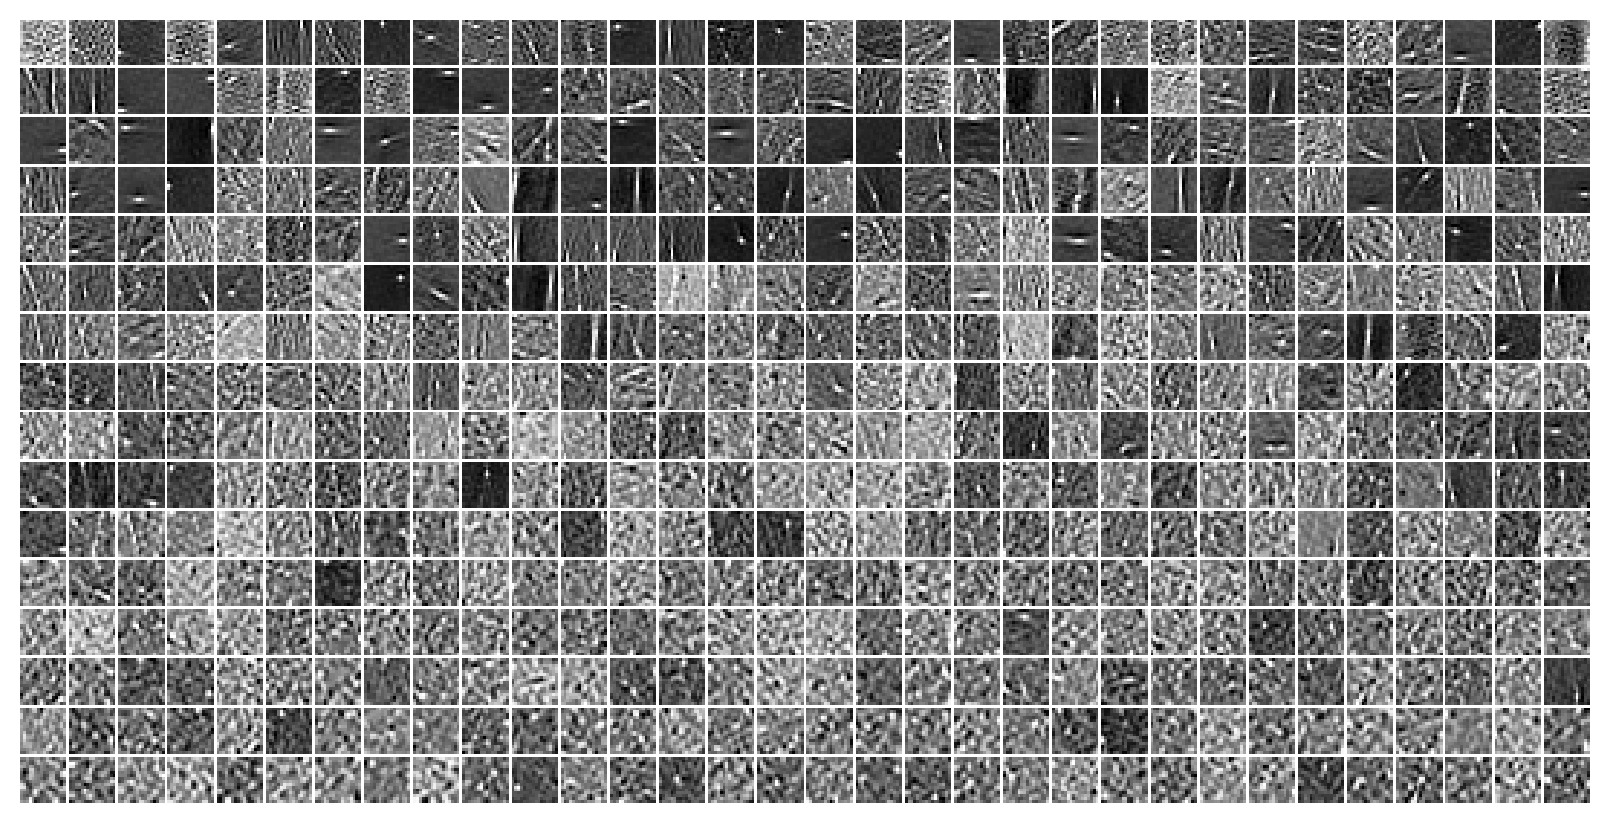

In [22]:
### Was w/ log_contrast

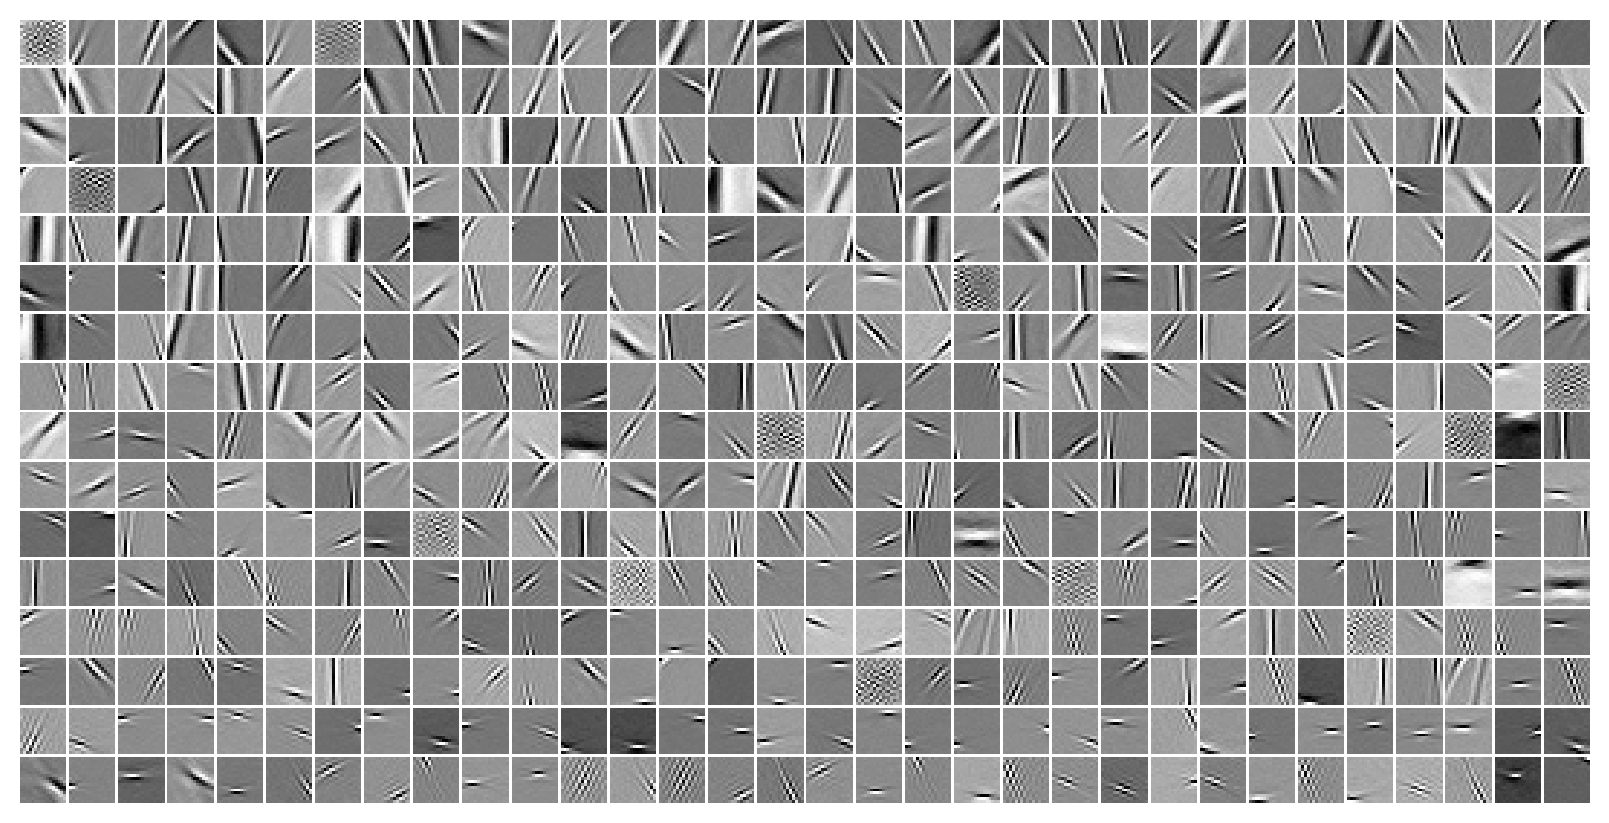

In [11]:
bias = tonp(tr.model.layer.log_bias.squeeze().exp())
tr.model.show(order=np.argsort(bias));

In [12]:
sp_stats.pearsonr(bias, u0)

PearsonRResult(statistic=-0.9277305565205826, pvalue=1.9982448200649475e-220)

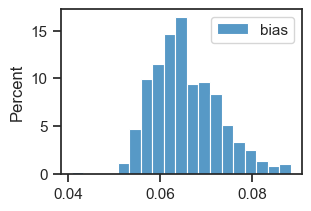

In [13]:
fig, ax = create_figure()

sns.histplot(bias, label='bias', stat='percent',  ax=ax)
ax.legend()
plt.show()

In [14]:
print(tr.model.layer.log_lr.exp())

tensor([0.1205], device='cuda:1', grad_fn=<ExpBackward0>)

100%|█████████████████████████████████| 20/20 [06:13<00:00, 18.69s/it]


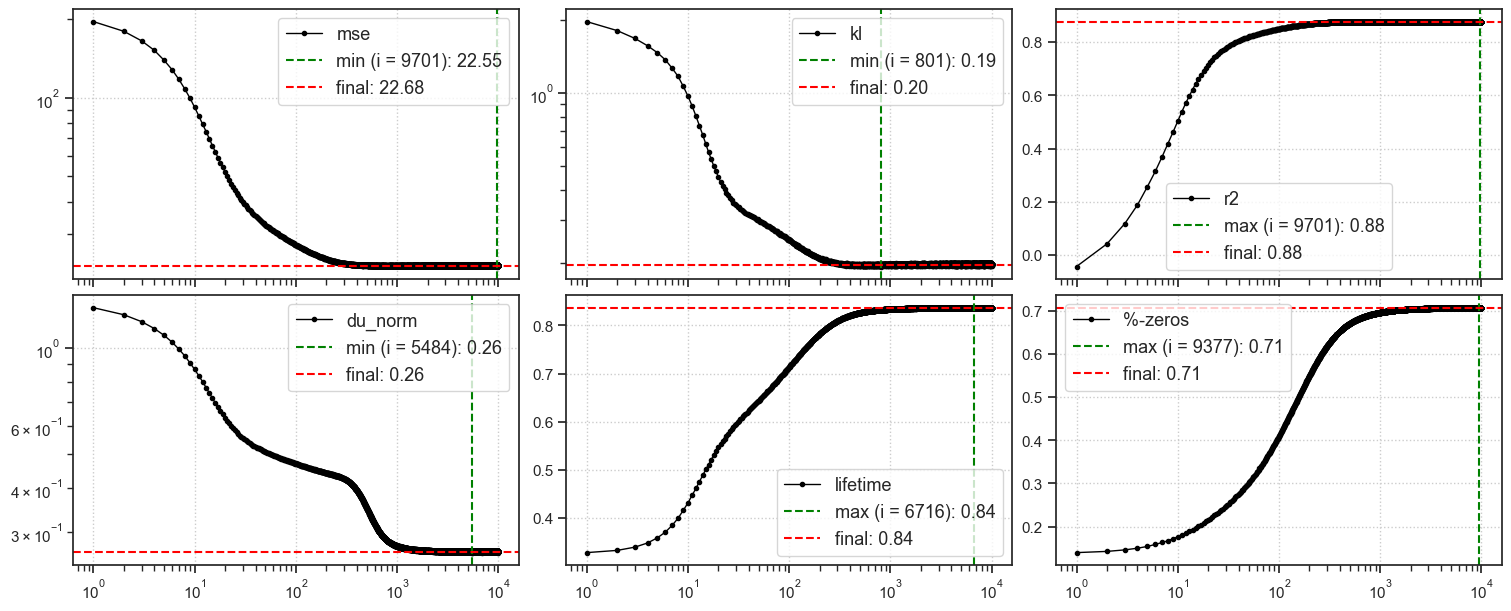

CPU times: user 8min 17s, sys: 10.1 s, total: 8min 27s
Wall time: 8min 27s


In [15]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=20,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

## output

In [16]:
%%time

output = tr.model.xtract_ftr(
    feeder=tr.get_feeder(),
    seq=range(1000),
    return_extras=True,
).stack()

print(list(output))

['loss_kl', 'loss_recon', 'posterior', 'du', 'u', 'v', 'recon', 'samples', 'conditional', 'mse', 'r2']

CPU times: user 1.72 s, sys: 19.5 ms, total: 1.74 s
Wall time: 1.74 s


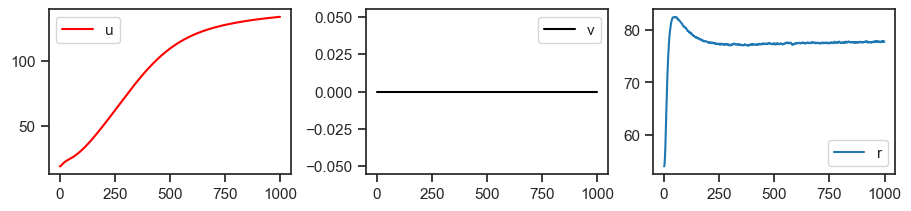

In [17]:
u_norm = tonp(torch.linalg.norm(output['u'], axis=-1).mean(0))
v_norm = tonp(torch.linalg.norm(output['v'], axis=-1).mean(0))
r_norm = tonp(torch.linalg.norm(torch.exp(output['u']), axis=-1).mean(0))

fig, axes = create_figure(1, 3)
axes[0].plot(u_norm, label='u', color='r')
axes[1].plot(v_norm, label='v', color='k')
axes[2].plot(r_norm, label='r')

add_legend(axes)
plt.show()

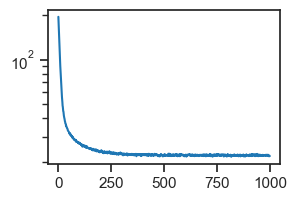

tensor([22.2474, 21.9888, 22.2276, 22.2255, 22.1008], device='cuda:1')

In [18]:
feeder = tr.get_feeder()

locs = torch.stack([
    p.loc for p in
    output['conditional'].values()
], dim=1)
mse = (locs - feeder[0].unsqueeze(1)).pow(2).sum(-1)
plot(mse.mean(0))
plt.yscale('log')
plt.show()

mse.mean(0)[-5:]

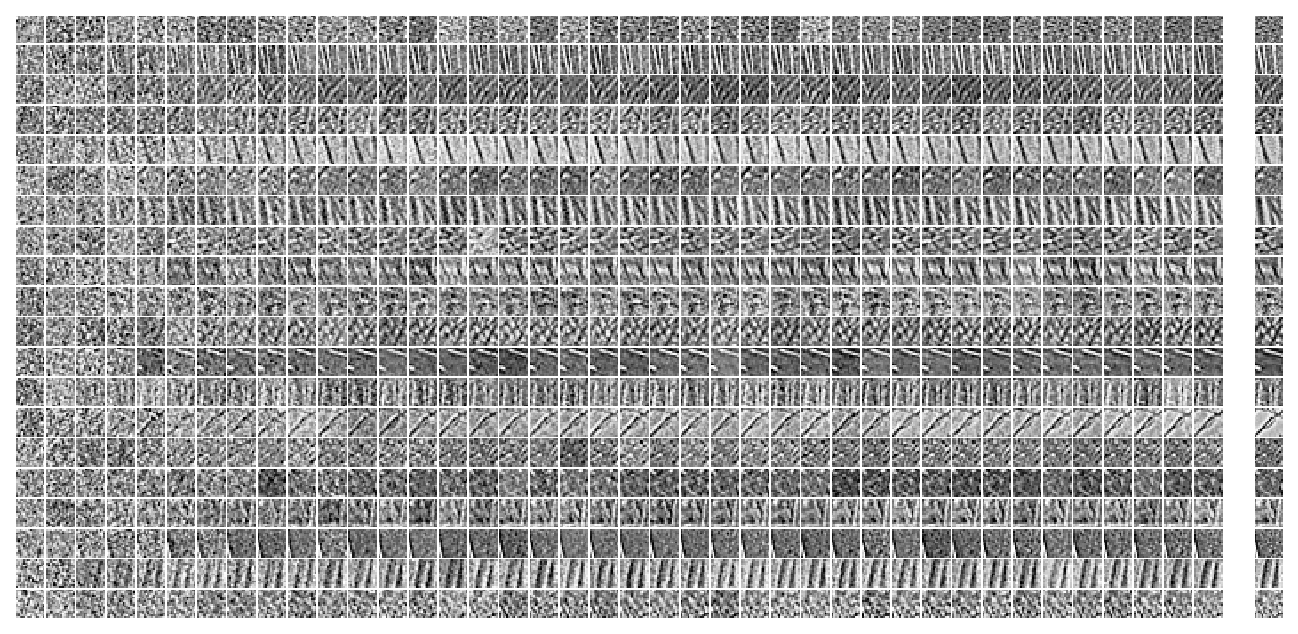

In [19]:
num = 20
n_timepoints = 40

x2p = tonp(locs)[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()

_ = plot_weights(x2p, nrows=num)

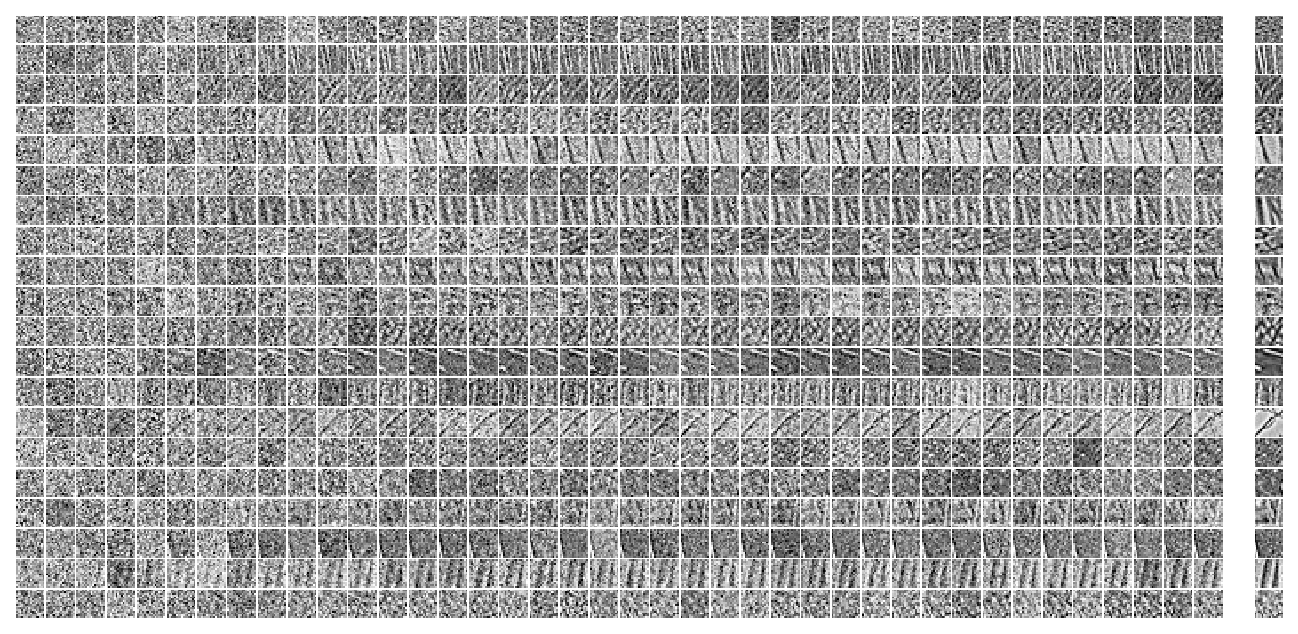

In [20]:
x2p = tonp(output['recon'])[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()

_ = plot_weights(x2p, nrows=num)